# Yale EMMLC Admission-Risk Logistic Regression

This notebook builds a Logistic Regression model to predict admission vs discharge using the cleaned Yale triage-time dataset. It compares train and test accuracy, recall, and precision in a single metrics dataframe.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = Path("yale_clean_triage.csv")
TARGET = "disposition_admit"
RANDOM_STATE = 42

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.utils.extmath")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.linear_model._linear_loss")

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)

y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])

## Class Balance

In [3]:
class_balance_df = pd.DataFrame({
    "class_label": ["discharge_0", "admit_1"],
    "count": [
        y.value_counts().sort_index().loc[0],
        y.value_counts().sort_index().loc[1],
    ],
    "percentage": [
        y.value_counts(normalize=True).sort_index().loc[0] * 100,
        y.value_counts(normalize=True).sort_index().loc[1] * 100,
    ],
})

class_balance_df

,class_label,count,percentage
0,discharge_0,393846,70.26891
1,admit_1,166638,29.73109


In [4]:
cc_columns = [column for column in X.columns if column.startswith("cc_")]
numeric_columns = [
    column
    for column in X.select_dtypes(include=[np.number]).columns
    if column not in cc_columns
]
categorical_columns = list(X.select_dtypes(include=["object", "category"]).columns)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [5]:
def make_balance_rows(split_name, target_values):
    counts = target_values.value_counts().sort_index()
    percentages = target_values.value_counts(normalize=True).sort_index().mul(100)
    return [
        {
            "split": split_name,
            "class_label": "discharge_0",
            "count": counts.loc[0],
            "percentage": percentages.loc[0],
        },
        {
            "split": split_name,
            "class_label": "admit_1",
            "count": counts.loc[1],
            "percentage": percentages.loc[1],
        },
    ]

split_balance_df = pd.DataFrame(
    make_balance_rows("full dataset", y)
    + make_balance_rows("train", y_train)
    + make_balance_rows("test", y_test)
)

split_balance_df

,split,class_label,count,percentage
0,full dataset,discharge_0,393846,70.268910
1,full dataset,admit_1,166638,29.731090
2,train,discharge_0,315077,70.268986
3,train,admit_1,133310,29.731014
4,test,discharge_0,78769,70.268607
5,test,admit_1,33328,29.731393


The full Yale dataset is imbalanced toward discharge.

The stratified train-test split preserves the admit/discharge ratio in both train and test.

Logistic Regression uses `class_weight="balanced"` so the model gives more weight to the admission class during training.

In [6]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

cc_pipeline = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="most_frequent"))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
        ("cc", cc_pipeline, cc_columns),
    ]
)

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

In [7]:
_ = pipeline.fit(X_train, y_train)

In [8]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

metrics_df = pd.DataFrame([
    {
        "split": "train",
        "accuracy": accuracy_score(y_train, y_train_pred),
        "recall": recall_score(y_train, y_train_pred, zero_division=0),
        "precision": precision_score(y_train, y_train_pred, zero_division=0),
    },
    {
        "split": "test",
        "accuracy": accuracy_score(y_test, y_test_pred),
        "recall": recall_score(y_test, y_test_pred, zero_division=0),
        "precision": precision_score(y_test, y_test_pred, zero_division=0),
    },
])

metrics_df

,split,accuracy,recall,precision
0,train,0.787188,0.803931,0.607358
1,test,0.787211,0.801398,0.607810


Train and test accuracy are almost the same, so there is no major train/test performance gap.

Recall is high on both train and test, so the model catches many admitted patients.

Precision is moderate on both train and test, so some predicted admissions are actually discharged patients.

## Full Performance Metrics

In [9]:
def full_metric_row(split, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    specificity = tn / (tn + fp) if (tn + fp) else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0
    return {
        "split": split,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
    }

full_metrics_df = pd.DataFrame([
    full_metric_row("train", y_train, y_train_pred),
    full_metric_row("test", y_test, y_test_pred),
])

full_metrics_df

,split,accuracy,precision,recall,specificity,f1
0,train,0.787188,0.607358,0.803931,0.780105,0.691955
1,test,0.787211,0.607810,0.801398,0.781208,0.691307


## ROC Curve and AUC

The ROC curve shows how well the baseline Logistic Regression model separates admitted and discharged patients across different probability thresholds. The AUC summarizes this separation ability in one score.

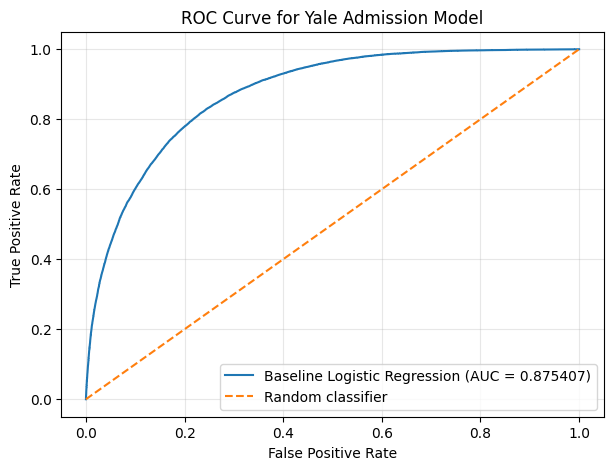

Baseline ROC-AUC: 0.875407


In [10]:
y_test_proba = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Baseline Logistic Regression (AUC = {auc_score:.6f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Yale Admission Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Baseline ROC-AUC: {auc_score:.6f}")

## GridSearchCV Model Tuning

GridSearchCV is used to tune the Logistic Regression step while keeping the same preprocessing pipeline. Recall is used for scoring because the model is predicting hospital admission, and catching actual admitted patients is important.

In [7]:
def metric_row(model_name, split, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0
    return {
        "model": model_name,
        "split": split,
        "accuracy": accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"],
    "model__max_iter": [1000, 2000],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="recall",
    cv=3,
    n_jobs=-1,
)

_ = grid_search.fit(X_train, y_train)

In [8]:
best_params = grid_search.best_params_
best_cv_recall = grid_search.best_score_

print("Best parameters:")
print(best_params)
print(f"Best cross-validation recall: {best_cv_recall:.6f}")

Best parameters:
{'model__C': 10, 'model__max_iter': 1000, 'model__solver': 'lbfgs'}
Best cross-validation recall: 0.803211


In [9]:
best_model = grid_search.best_estimator_

y_train_tuned_pred = best_model.predict(X_train)
y_test_tuned_pred = best_model.predict(X_test)

tuned_metrics_df = pd.DataFrame([
    metric_row("Tuned Logistic Regression", "train", y_train, y_train_tuned_pred),
    metric_row("Tuned Logistic Regression", "test", y_test, y_test_tuned_pred),
]).drop(columns=["model"])

tuned_metrics_df

,split,accuracy,recall,precision,specificity,f1
0,train,0.787104,0.803856,0.607240,0.780016,0.691850
1,test,0.787131,0.801338,0.607695,0.781119,0.691211


In [10]:
baseline_test_row = metric_row("Baseline Logistic Regression", "test", y_test, y_test_pred)
tuned_test_row = metric_row("Tuned Logistic Regression", "test", y_test, y_test_tuned_pred)

model_comparison_df = pd.DataFrame([baseline_test_row, tuned_test_row])[
    ["model", "accuracy", "recall", "precision", "specificity", "f1"]
]

model_comparison_df

,model,accuracy,recall,precision,specificity,f1
0,Baseline Logistic Regression,0.787211,0.801398,0.607810,0.781208,0.691307
1,Tuned Logistic Regression,0.787131,0.801338,0.607695,0.781119,0.691211
